# Métodos de ensamble: Random Forest, AdaBoost y Gradient Boosting
### Clasificando correos como *spam* o *ham*

**Objetivo de este notebook.** Ver, con un dataset diminuto que cabe en una sola gráfica, por qué **combinar muchos modelos débiles** suele funcionar mejor que un solo modelo muy complejo.

**Ruta de la sesión**

| # | Paso | Idea clave |
|---|------|-----------|
| 1 | Un solo árbol de decisión | Puede memorizar los datos → *overfitting* |
| 2 | Random forest "a mano" | Varios árboles simples entrenados en partes distintas de los datos + **votación** |
| 3 | Random forest con `sklearn` | Lo mismo, pero con *bootstrap* y selección aleatoria de variables |
| 4 | AdaBoost | Árboles **en secuencia**: cada uno se enfoca en los errores del anterior |
| 5 | Gradient Boosting y XGBoost | Cada árbol nuevo corrige el **residuo** del modelo acumulado |

> **Dos familias de ensambles**
> - **Bagging** (*bootstrap aggregating*, p. ej. Random Forest): los modelos se entrenan **en paralelo** e independientes; al final **votan**. Principalmente **reduce la varianza** (el overfitting).
> - **Boosting** (AdaBoost, Gradient Boosting, XGBoost): los modelos se entrenan **en secuencia**; cada uno aprende de los errores del anterior. Principalmente **reduce el sesgo** (el underfitting).

## 1. Importar librerías

- **`pandas`**: manejar los datos en forma de tabla (`DataFrame`).
- **`numpy`**: operaciones con arreglos numéricos.
- **`matplotlib.pyplot`**: gráficas.
- **`DecisionTreeClassifier`** y **`tree`** (de `scikit-learn`): el árbol de decisión, que será el "ladrillo" de todos los ensambles de hoy.

`np.random.seed(0)` fija la semilla aleatoria para que **todos obtengamos los mismos resultados** cada vez que corremos el notebook.

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# Semilla para que los resultados sean reproducibles
np.random.seed(0)

# Ocultamos dos advertencias inofensivas para que la salida quede limpia en clase:
# 1) sklearn avisa cuando entrenamos con un DataFrame (con nombres de columnas)
#    y luego predecimos con un arreglo de numpy (sin nombres). No afecta el resultado.
# 2) matplotlib avisa cuando un modelo predice la misma clase en todo el plano
#    (no hay frontera que dibujar).
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")
warnings.filterwarnings("ignore", message="No contour levels were found")

## 2. Funciones auxiliares para graficar

No es necesario entender cada línea de esta celda; lo importante es **qué hace cada función**:

- **`plot_points(features, labels)`**: dibuja los correos en el plano. Triángulos cian = **spam** (1), cuadrados rojos = **ham** (0, correo legítimo).
- **`plot_model(X, y, model)`**: dibuja la **frontera de decisión** de un modelo. ¿Cómo? Crea una malla muy fina de puntos que cubre todo el plano (`np.meshgrid`), le pide al modelo que prediga cada punto (`model.predict`) y colorea cada zona según la clase predicha. La línea negra es la frontera entre "spam" y "ham".
- **`display_tree(dt)`**: dibuja la estructura interna de un árbol (sus preguntas y sus hojas).

> 🔧 **Nota:** la versión original de `display_tree` usaba `pydotplus` y Graphviz, que requieren instalación adicional. Esta versión usa `tree.plot_tree` de `scikit-learn`, que funciona sin instalar nada más.

In [2]:
# ---------------------------------------------------------------
# Dibuja los puntos: spam (1) = triángulos cian, ham (0) = cuadrados rojos
# ---------------------------------------------------------------
def plot_points(features, labels, fix_margins=True):
    X = np.array(features)
    y = np.array(labels)
    spam = X[np.argwhere(y==1)]   # filas cuya etiqueta es 1
    ham = X[np.argwhere(y==0)]    # filas cuya etiqueta es 0
    if fix_margins:               # ejes fijos de 0 a 11 para comparar gráficas
        plt.xlim(0, 11)
        plt.ylim(0, 11)
    plt.scatter([s[0][0] for s in spam],
                [s[0][1] for s in spam],
                s = 100,
                color = 'cyan',
                edgecolor = 'k',
                marker = '^')
    plt.scatter([s[0][0] for s in ham],
                [s[0][1] for s in ham],
                s = 100,
                color = 'red',
                edgecolor = 'k',
                marker = 's')
    plt.xlabel('Lottery')
    plt.ylabel('Sale')
    plt.legend(['Spam','Ham'])

# ---------------------------------------------------------------
# Dibuja la frontera de decisión de cualquier modelo con .predict()
# ---------------------------------------------------------------
def plot_model(X, y, model, fix_margins=True):
    X = np.array(X)
    y = np.array(y)
    plot_points(X, y)
    plot_step = 0.01              # resolución de la malla
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    if fix_margins:
        x_min=0
        y_min=0
        x_max=12
        y_max=12
    # 1) Malla de puntos que cubre todo el plano
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    # 2) El modelo predice la clase de cada punto de la malla
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    # 3) Colorear las zonas (rojo = ham, azul = spam) y trazar la frontera en negro
    plt.contourf(xx, yy, Z, colors=['red', 'blue'], alpha=0.2, levels=range(-1,2))
    plt.contour(xx, yy, Z,colors = 'k',linewidths = 3)
    plt.show()

# ---------------------------------------------------------------
# Dibuja la estructura de un árbol (no requiere Graphviz)
# ---------------------------------------------------------------
def display_tree(dt, feature_names=('Lottery', 'Sale')):
    # Tamaño de la figura según la profundidad del árbol
    depth = dt.get_depth()
    plt.figure(figsize=(max(6, 3 * depth), max(4, 1.8 * (depth + 1))))
    # Nombres de clase solo si es un clasificador (Gradient Boosting usa árboles de regresión)
    class_names = ['Ham', 'Spam'] if hasattr(dt, 'classes_') else None
    tree.plot_tree(dt, feature_names=list(feature_names), class_names=class_names,
                   filled=True, rounded=True, fontsize=10)
    plt.show()

## 3. El dataset de correos

Tenemos **18 correos**. De cada uno medimos dos características:

- **`Lottery`**: cuántas veces aparece la palabra *"lottery"* en el correo.
- **`Sale`**: cuántas veces aparece la palabra *"sale"*.

Y la etiqueta que queremos predecir:

- **`Spam`**: `1` si el correo es spam, `0` si es un correo legítimo (*ham*).

El dataset está **balanceado**: 9 spam y 9 ham. Es un dataset de juguete, a propósito: con solo 2 variables podemos **ver** en una gráfica lo que hace cada modelo.

In [3]:
# Cada fila es un correo: [Lottery, Sale, Spam]
emails = np.array([
    [7,8,1],
    [3,2,0],
    [8,4,1],
    [2,6,0],
    [6,5,1],
    [9,6,1],
    [8,5,0],
    [7,1,0],
    [1,9,1],
    [4,7,0],
    [1,3,0],
    [3,10,1],
    [2,2,1],
    [9,3,0],
    [5,3,0],
    [10,1,0],
    [5,9,1],
    [10,8,1],
])
spam_dataset = pd.DataFrame(data=emails, columns=["Lottery", "Sale", "Spam"])
spam_dataset

,Lottery,Sale,Spam
0,7,8,1
1,3,2,0
2,8,4,1
3,2,6,0
4,6,5,1
5,9,6,1
6,8,5,0
7,7,1,0
8,1,9,1
9,4,7,0


### Visualicemos los datos

Separamos las **variables de entrada** (`features`: *Lottery* y *Sale*) de la **variable objetivo** (`labels`: *Spam*) y los graficamos.

> 💬 **Pregunta para la clase:** ¿Se pueden separar los triángulos de los cuadrados con **una sola línea recta**? ¿Y con líneas horizontales/verticales (que es lo único que puede trazar un árbol de decisión)?

Observen que hay puntos "incómodos", como el spam en (2, 2) rodeado de hams, o el ham en (8, 5) rodeado de spams. Esos puntos van a ser clave para entender el *overfitting*.

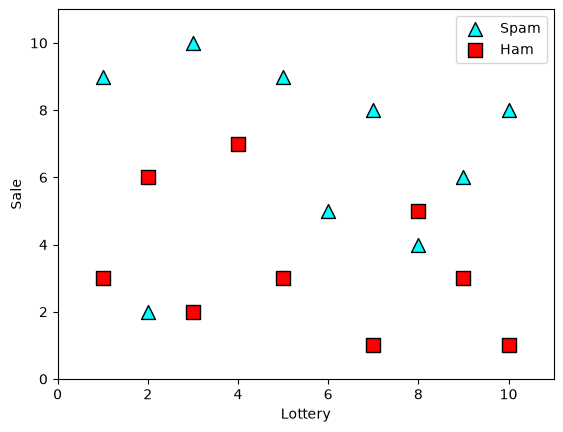

In [4]:
features = spam_dataset[['Lottery', 'Sale']]   # X: variables de entrada
labels = spam_dataset['Spam']                   # y: variable objetivo
plot_points(features, labels)

## 4. Punto de partida: un solo árbol de decisión

Entrenamos un árbol de decisión **sin ninguna restricción** (sin límite de profundidad). El patrón de `scikit-learn` es siempre el mismo:

1. **Crear** el modelo → `DecisionTreeClassifier(...)`
2. **Entrenar** → `.fit(X, y)`
3. **Evaluar** → `.score(X, y)` devuelve el *accuracy* (proporción de aciertos).

> ⚠️ Aquí evaluamos con **los mismos datos** con los que entrenamos. Eso mide qué tan bien el modelo **memorizó**, no qué tan bien **generaliza**. Lo usamos solo para comparar modelos en este ejemplo visual.

In [5]:
decision_tree_classifier = DecisionTreeClassifier(random_state=0)   # sin límite de profundidad
decision_tree_classifier.fit(features, labels)                      # entrenar
decision_tree_classifier.score(features, labels)                    # accuracy en entrenamiento

1.0

**Accuracy = 1.0 (100 %).** El árbol clasifica perfectamente los 18 correos.

> 💬 **Pregunta para la clase:** ¿Es eso una buena noticia? Si llega un correo nuevo, ¿creen que también acertará?

Veamos **cómo** logró ese 100 %.

### Estructura del árbol

Cada caja es una **pregunta** sobre una variable (p. ej. `Sale <= 7.5`). Si la respuesta es verdadera se va a la izquierda; si es falsa, a la derecha. Las cajas finales (**hojas**) dan la predicción.

Dentro de cada caja:
- **`gini`**: impureza del nodo (0 = todos los correos de la misma clase).
- **`samples`**: cuántos correos llegan a ese nodo.
- **`value`**: cuántos hay de cada clase `[ham, spam]`.
- **`class`**: la clase mayoritaria (la predicción).

Observen que el árbol llega a **profundidad 6** con **9 hojas** para solo 18 correos: está haciendo preguntas muy específicas para acomodar puntos individuales.

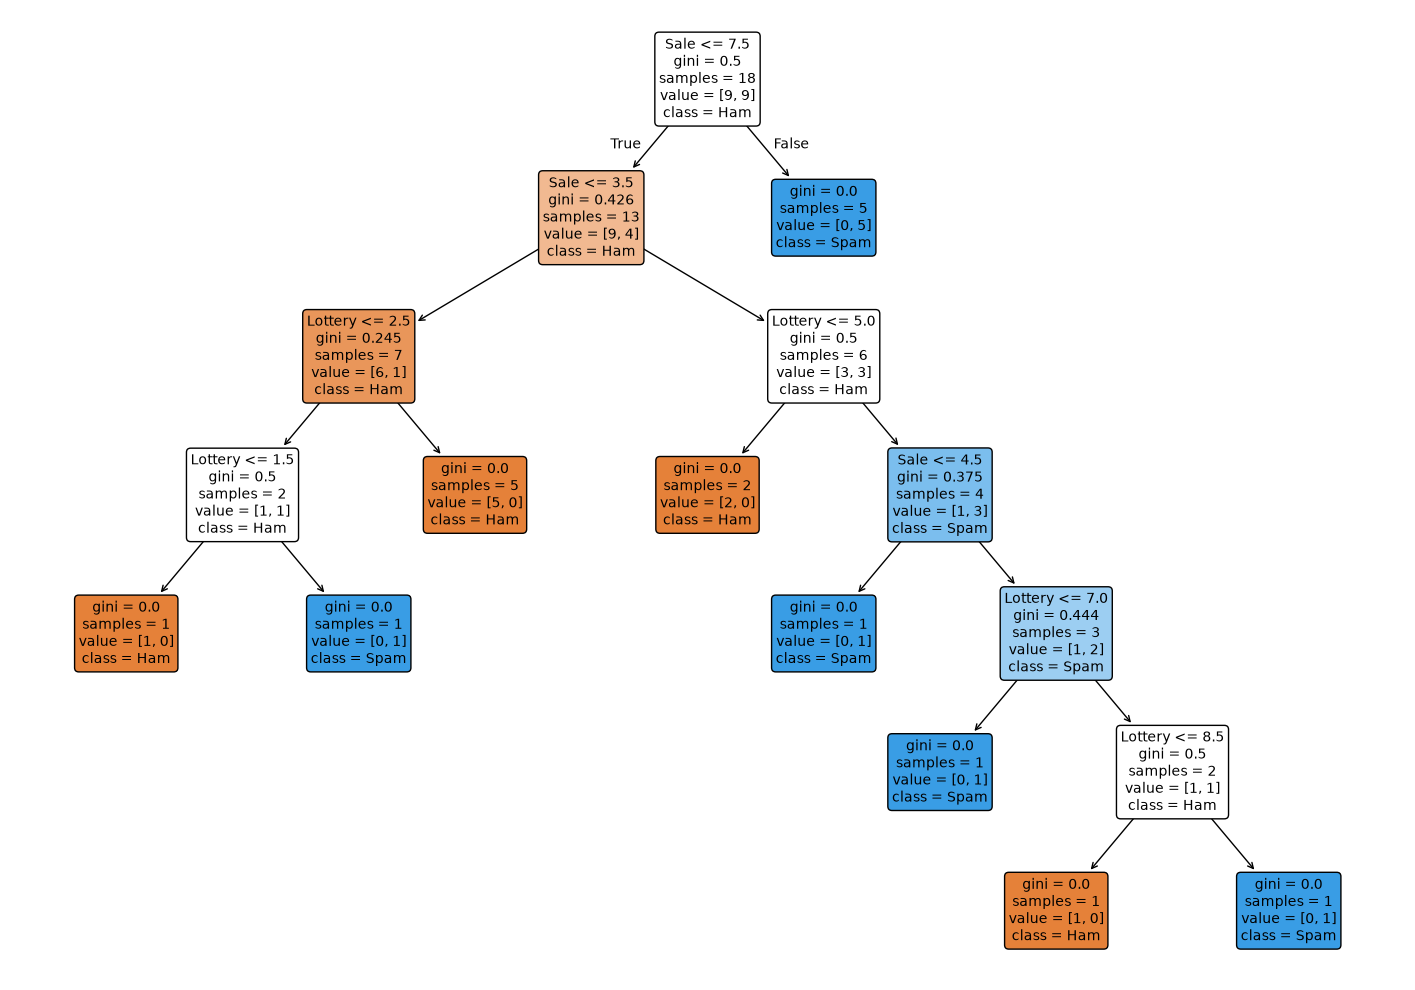

In [6]:
display_tree(decision_tree_classifier)

### Frontera de decisión del árbol

Zona **azul** = el modelo predice spam; zona **roja** = predice ham.

Fíjense en las "islas" y rectángulos pequeños alrededor de puntos aislados: el árbol dibuja fronteras muy recortadas para no equivocarse con **ningún** punto. Eso es **overfitting**: el modelo aprende también el **ruido** de los datos. Con un correo nuevo, es probable que falle.

**La idea de los ensambles:** en lugar de un árbol profundo y complejo, combinar **muchos árboles simples**.

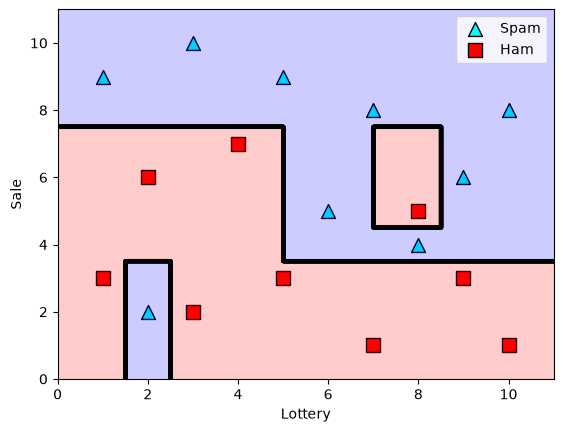

In [7]:
plot_model(features, labels, decision_tree_classifier)

## 5. Random forest "a mano"

Un **random forest** entrena varios árboles, cada uno viendo **una parte distinta de los datos**, y luego los hace **votar**.

Para entender la idea, lo haremos manualmente con una versión simplificada:

1. Partimos los 18 correos en **3 lotes de 6** correos cada uno.
2. Entrenamos un árbol **muy simple** en cada lote.
3. Combinamos los 3 árboles por **votación por mayoría**.

> 📝 Un random forest real hace dos cosas más: (a) cada árbol toma una muestra **con reemplazo** (*bootstrap*) del dataset completo, en vez de lotes disjuntos; y (b) en cada división el árbol considera solo un **subconjunto aleatorio de variables**. Lo veremos con `sklearn` en la sección 6.

### Paso 1: dividir los datos en 3 lotes

`spam_dataset.loc[[...]]` selecciona filas por su índice. Graficamos cada lote por separado.

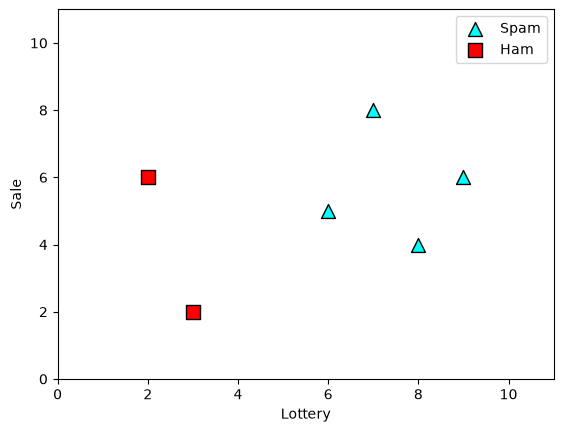

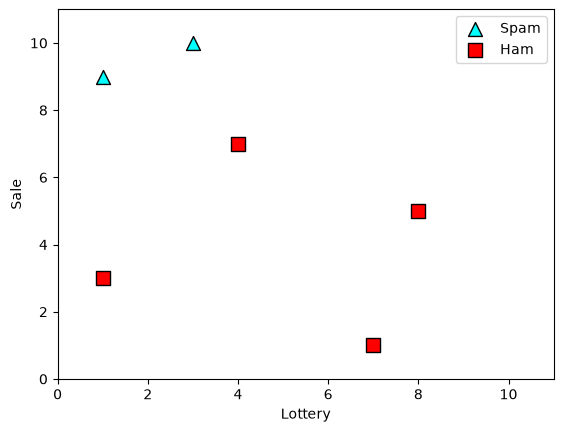

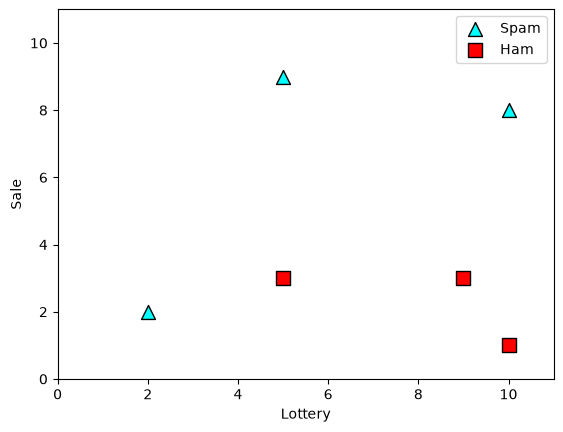

In [8]:
# Lote 1: correos 0 a 5
first_batch = spam_dataset.loc[[0,1,2,3,4,5]]
features1 = first_batch[['Lottery', 'Sale']]
labels1 = first_batch['Spam']
plot_points(features1, labels1)
plt.show()

# Lote 2: correos 6 a 11
second_batch = spam_dataset.loc[[6,7,8,9,10,11]]
features2 = second_batch[['Lottery', 'Sale']]
labels2 = second_batch['Spam']
plot_points(features2, labels2)
plt.show()

# Lote 3: correos 12 a 17
third_batch = spam_dataset.loc[[12,13,14,15,16,17]]
features3 = third_batch[['Lottery', 'Sale']]
labels3 = third_batch['Spam']
plot_points(features3, labels3)

### Paso 2: entrenar un "aprendiz débil" en cada lote

Usamos `max_depth=1`: cada árbol puede hacer **una sola pregunta**. A este árbol mínimo se le llama **muñón** (*decision stump*). Es un **aprendiz débil** (*weak learner*): por sí solo es apenas mejor que adivinar, pero es rápido y difícilmente hace overfitting.

Para cada árbol la celda muestra: su accuracy **en su propio lote**, su estructura y su frontera de decisión (una sola línea recta horizontal o vertical).

Lo que deberían ver:

| Árbol | Pregunta que aprende | Accuracy en su lote |
|-------|----------------------|---------------------|
| `dt1` | `Lottery <= 4.5` → ham | 1.00 |
| `dt2` | `Sale <= 8.0` → ham | 1.00 |
| `dt3` | `Sale <= 5.5` → ham | 0.83 |

> 💬 **Pregunta para la clase:** cada árbol aprendió una regla **distinta** porque vio datos distintos. ¿Alguna de estas reglas por sí sola les parece suficiente para todo el dataset?

Weak learner 1 training accuracy: 1.0


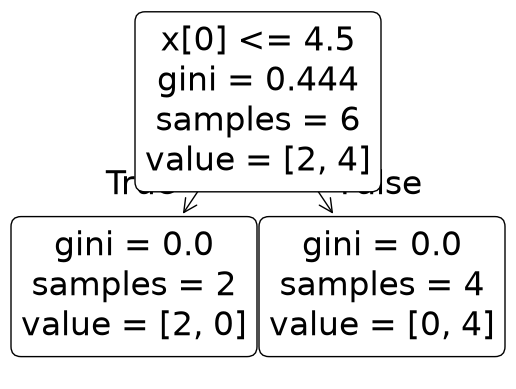

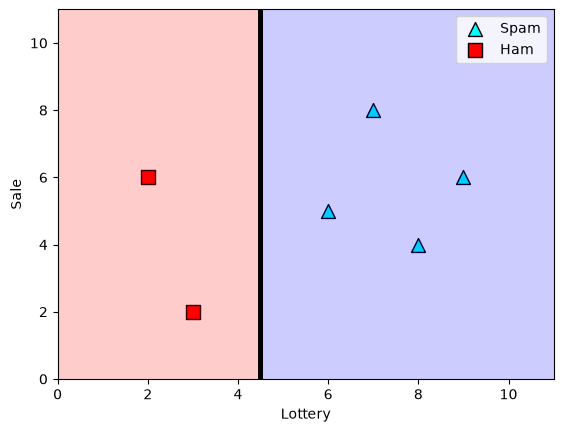

Weak learner 2 training accuracy: 1.0


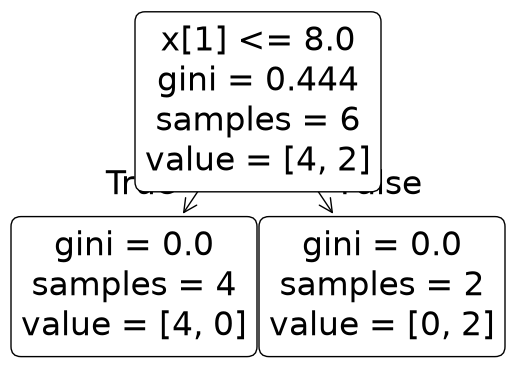

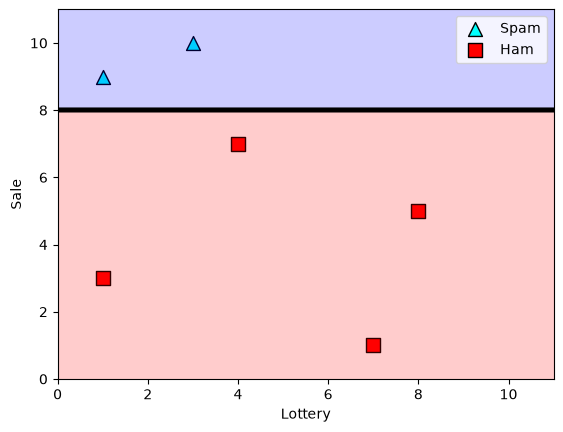

Weak learner 3 training accuracy: 0.8333333333333334


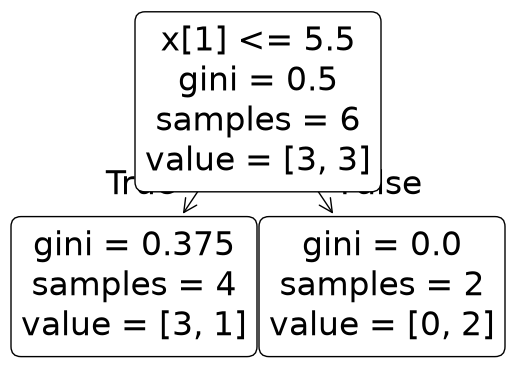

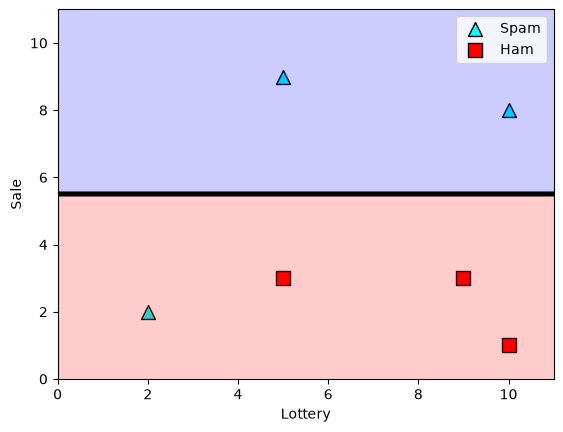

In [9]:
# --- Árbol 1: entrenado solo con el lote 1 ---
dt1 = DecisionTreeClassifier(random_state=0, max_depth=1)   # max_depth=1 → una sola pregunta
dt1.fit(features1, labels1)
print("Weak learner 1 training accuracy:", dt1.score(features1, labels1))
tree.plot_tree(dt1, rounded=True)
plt.show()
plot_model(features1, labels1, dt1)

# --- Árbol 2: entrenado solo con el lote 2 ---
dt2 = DecisionTreeClassifier(random_state=0, max_depth=1)
dt2.fit(features2, labels2)
print("Weak learner 2 training accuracy:", dt2.score(features2, labels2))
tree.plot_tree(dt2, rounded=True)
plt.show()
plot_model(features2, labels2, dt2)

# --- Árbol 3: entrenado solo con el lote 3 ---
dt3 = DecisionTreeClassifier(random_state=0, max_depth=1)
dt3.fit(features3, labels3)
print("Weak learner 3 training accuracy:", dt3.score(features3, labels3))
tree.plot_tree(dt3, rounded=True)
plt.show()
plot_model(features3, labels3, dt3)

Las mismas tres estructuras, con los nombres de las variables y colores para leerlas más fácil:

**Árbol 1** (lote 1): divide por `Lottery`.

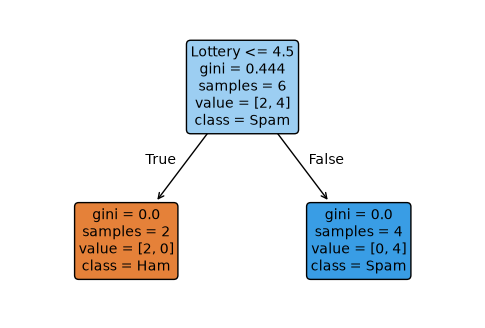

In [10]:
display_tree(dt1)

**Árbol 2** (lote 2): divide por `Sale`, en 8.

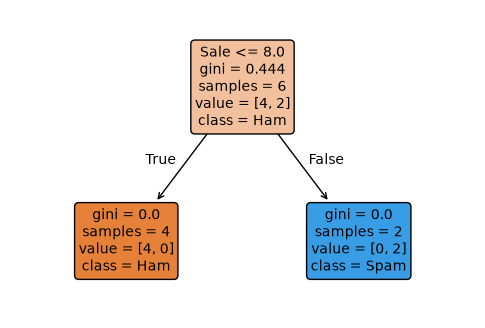

In [11]:
display_tree(dt2)

**Árbol 3** (lote 3): divide por `Sale`, en 5.5.

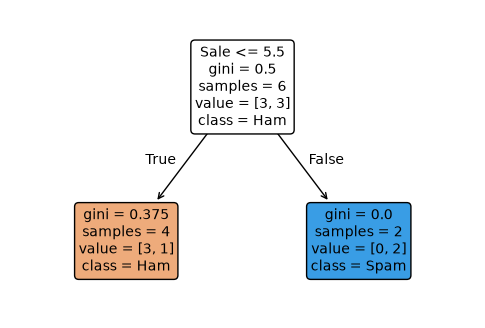

In [12]:
display_tree(dt3)

### Paso 3: combinar los tres árboles por votación

Aquí está la magia del ensamble. Para cada correo, los 3 árboles dan su predicción y gana la **mayoría** (al menos 2 de 3 votos).

Primero medimos a cada árbol **solo** sobre los 18 correos, y luego al **equipo** votando:

- Árbol 1 solo: ≈ 0.56 de accuracy
- Árbol 2 solo: ≈ 0.67 de accuracy
- Árbol 3 solo: ≈ 0.72 de accuracy
- **Los tres votando: ≈ 0.83 de accuracy** ✨

Ningún árbol individual supera el 72 % de accuracy, pero juntos llegan al 83 %: **los errores de uno se compensan con los aciertos de los otros**. Esa es la idea central de todos los ensambles.

Observen también la frontera: es una "escalera" formada por las 3 líneas rectas, mucho más simple que la del árbol profundo de la sección 4.

Árbol 1 solo:          0.56
Árbol 2 solo:          0.67
Árbol 3 solo:          0.72
Los tres votando juntos: 0.83


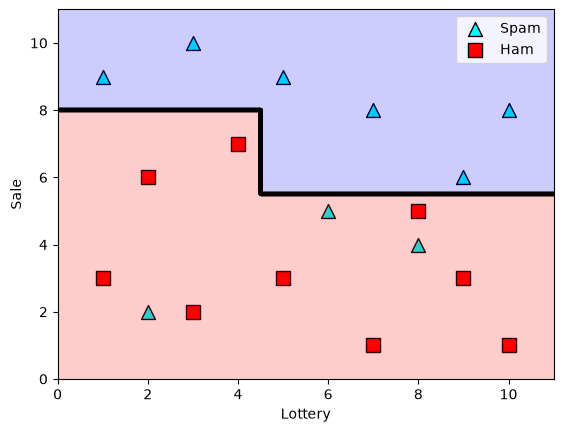

In [13]:
# Un "modelo" mínimo que combina varios árboles por votación por mayoría.
# Tiene un método .predict(), así que podemos pasarlo a plot_model().
class VotacionPorMayoria:
    def __init__(self, modelos):
        self.modelos = modelos

    def predict(self, X):
        X = np.array(X)
        votos = np.array([m.predict(X) for m in self.modelos])   # una fila de votos por árbol
        return (votos.mean(axis=0) > 0.5).astype(int)            # gana la mayoría

    def score(self, X, y):
        return (self.predict(X) == np.array(y)).mean()

bosque_manual = VotacionPorMayoria([dt1, dt2, dt3])

# Cada árbol por separado, evaluado en los 18 correos
for nombre, modelo in [("Árbol 1", dt1), ("Árbol 2", dt2), ("Árbol 3", dt3)]:
    print(f"{nombre} solo:          {modelo.score(np.array(features), labels):.2f}")

# Los tres votando juntos
print(f"Los tres votando juntos: {bosque_manual.score(features, labels):.2f}")

plot_model(features, labels, bosque_manual)

## 6. Random forest con `scikit-learn`

Ahora dejamos que `RandomForestClassifier` haga todo el trabajo. Los parámetros que usamos:

- **`n_estimators=5`**: número de árboles en el bosque.
- **`max_depth=1`**: cada árbol es un muñon (una sola pregunta), igual que en nuestra versión manual.
- **`random_state=0`**: para que el resultado sea reproducible.

Lo que `sklearn` hace distinto a nuestra versión manual:

1. **Bootstrap**: cada árbol se entrena con una muestra aleatoria **con reemplazo** de los 18 correos (algunos correos aparecen repetidos y otros no aparecen).
2. **Selección aleatoria de variables** (`max_features="sqrt"` por defecto): en cada división el árbol solo puede elegir entre un subconjunto de variables. Con 2 variables, √2 ≈ 1, así que **cada muñón (Desicion Stump) solo ve una variable elegida al azar**. Eso hace que los árboles sean más distintos entre sí, lo que mejora la votación.
3. **Votación "suave"**: en vez de contar votos, promedia las **probabilidades** que da cada árbol.

Resultado esperado: **accuracy ≈ 0.83**.

In [14]:
from sklearn.ensemble import RandomForestClassifier

random_forest_classifier = RandomForestClassifier(random_state=0, n_estimators=5, max_depth=1)
random_forest_classifier.fit(features, labels)
random_forest_classifier.score(features, labels)

0.8333333333333334

### Frontera de decisión del random forest

Comparen con la del árbol profundo (sección 4): la frontera es **más simple y más "suave"**. Se equivoca en algunos puntos de entrenamiento, pero a cambio no está persiguiendo cada punto raro. Este tipo de modelo suele **generalizar mejor**.

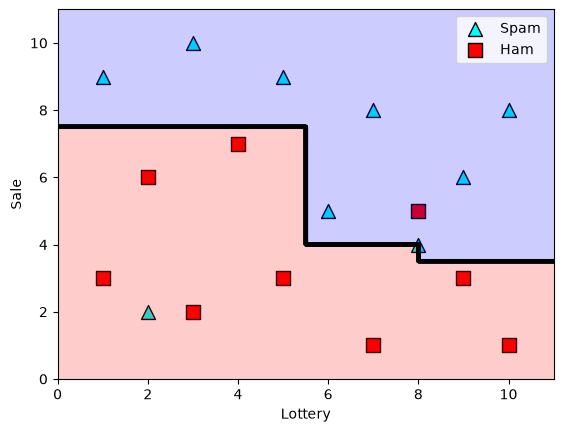

In [15]:
plot_model(features, labels, random_forest_classifier)

### Los 5 árboles del bosque, uno por uno

El atributo `.estimators_` contiene la lista de árboles ya entrenados. Para cada uno mostramos su estructura y su frontera **sobre el dataset completo**.

Observen que:
- Unos árboles preguntan por `Lottery` (`x[0]`) y otros por `Sale` (`x[1]`): es la **selección aleatoria de variables** en acción.
- Los umbrales cambian de un árbol a otro porque cada uno vio una **muestra bootstrap** distinta.
- Algún árbol puede salir **de un solo color** (predice la misma clase a ambos lados de su pregunta): con su muestra bootstrap, la división no le cambió la clase mayoritaria. Es un árbol "inútil" por sí solo, pero en el promedio sigue aportando información a través de sus probabilidades.

****************************** Estimator ******************************


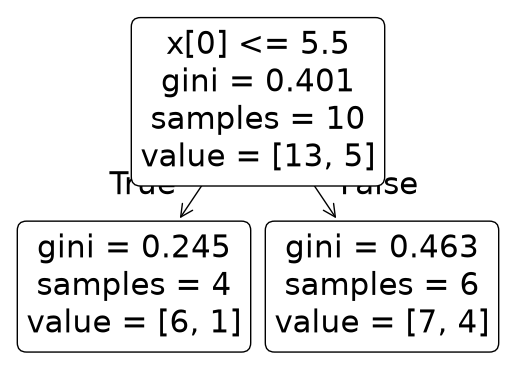

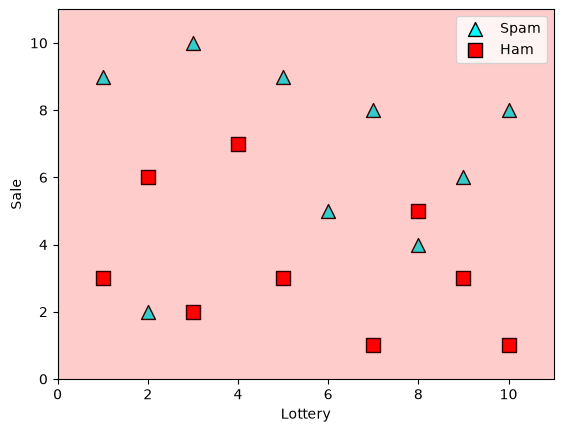

****************************** Estimator ******************************


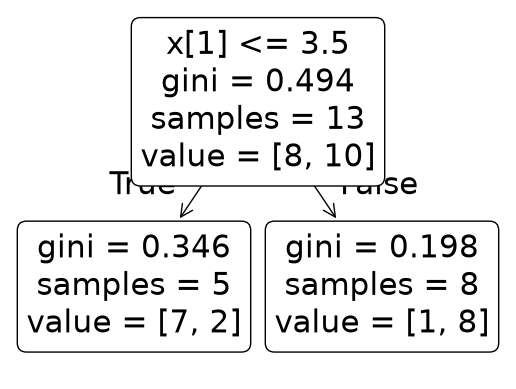

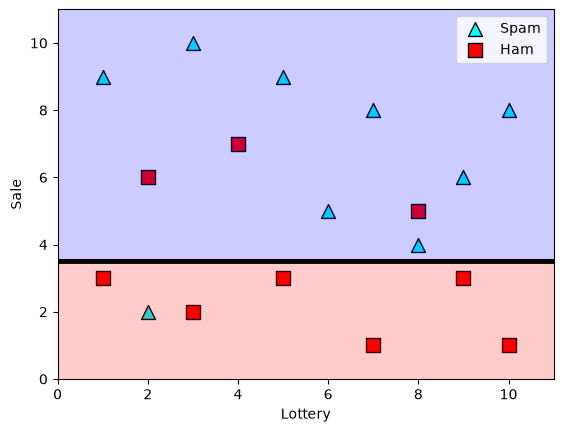

****************************** Estimator ******************************


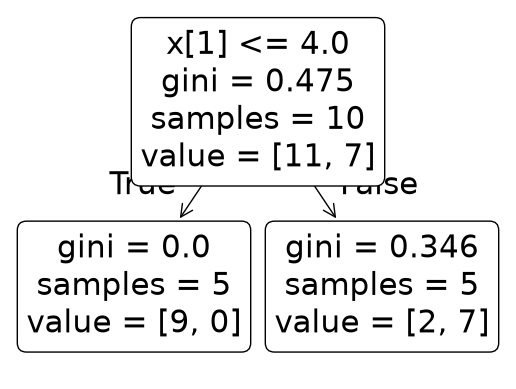

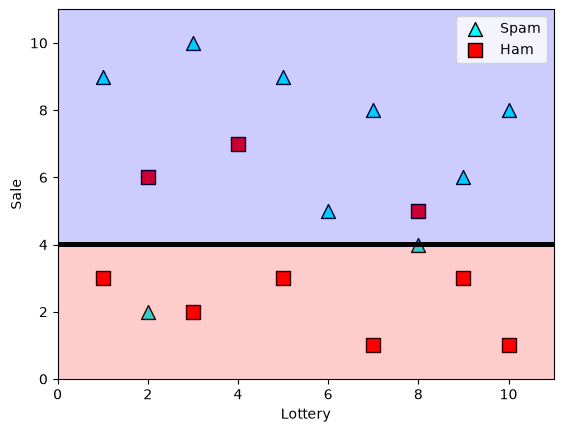

****************************** Estimator ******************************


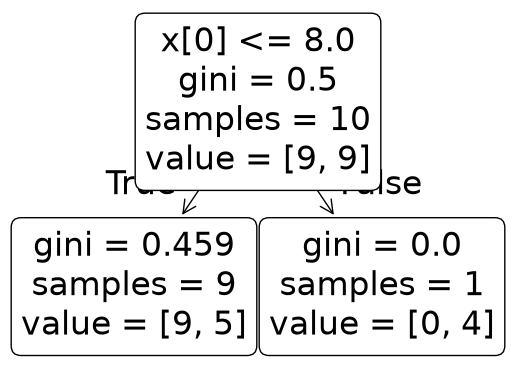

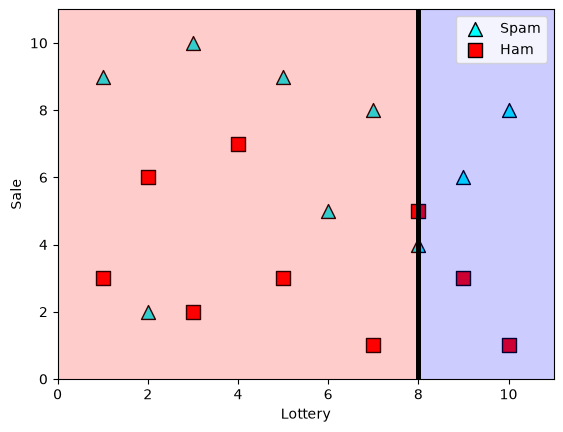

****************************** Estimator ******************************


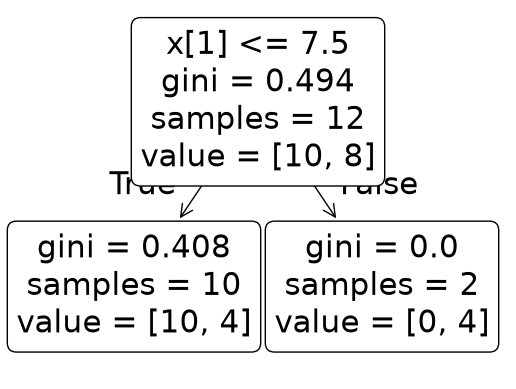

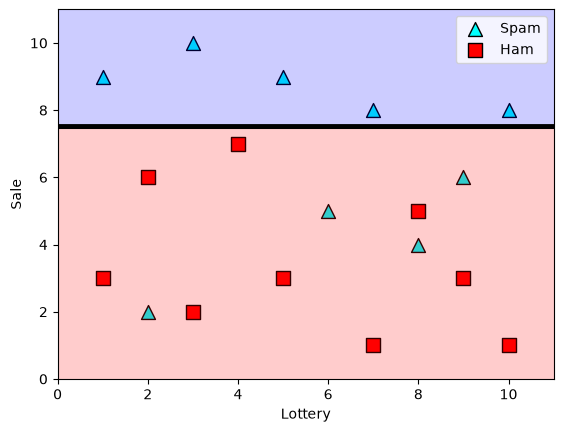

In [16]:
for dt in random_forest_classifier.estimators_:
    print("*"*30, "Estimator", "*"*30)
    tree.plot_tree(dt, rounded=True)          # estructura del árbol (x[0]=Lottery, x[1]=Sale)
    plt.show()
    plot_model(features, labels, dt)          # su frontera sobre todos los datos
    plt.show()

## 7. AdaBoost (*Adaptive Boosting*)

Cambiamos de familia: de **bagging** a **boosting**.

En Random Forest los árboles son **independientes**. En AdaBoost se entrenan **uno después del otro**, y cada uno **aprende de los errores del anterior**:

1. Al inicio todos los correos pesan lo mismo.
2. Se entrena un muñón (Desicion Stump) (`max_depth=1`, el estimador por defecto de AdaBoost).
3. Los correos que ese Desicion Stump **clasificó mal** ganan **más peso**; los bien clasificados, menos.
4. El siguiente Desicion Stump se entrena con esos pesos, así que se ve "obligado" a prestar atención a los casos difíciles.
5. Se repite `n_estimators` veces.

Al final, los muñones (o weak learners) **votan de forma ponderada**: cada uno tiene un peso (*alpha*) que depende de su error. Un muñón (Desicion Stump) con poco error vota con más fuerza:

$$\alpha = \ln\left(\frac{1 - \text{error}}{\text{error}}\right)$$

Parámetros: **`n_estimators=6`** (seis muñones en secuencia) y `random_state=0`.


El patrón de `scikit-learn` es siempre el mismo:

1. **Crear** el modelo → `AdaBoostClassifier(...)`
2. **Entrenar** → `.fit(X, y)`
3. **Evaluar** → `.score(X, y)` devuelve el *accuracy* (proporción de aciertos).

Resultado esperado: **accuracy ≈ 0.78**.

In [17]:
from sklearn.ensemble import AdaBoostClassifier

# random_state fijo para obtener siempre el mismo resultado
adaboost_classifier = AdaBoostClassifier(random_state=0, n_estimators=6)
adaboost_classifier.fit(features, labels)
adaboost_classifier.score(features, labels)

0.7777777777777778

### Frontera de decisión de AdaBoost

AdaBoost obtiene aquí un accuracy de entrenamiento algo menor que el random forest. Con solo 18 puntos y 6 muñones esto **no** significa que un método sea mejor que el otro; ambos producen fronteras mucho más simples que el árbol profundo.

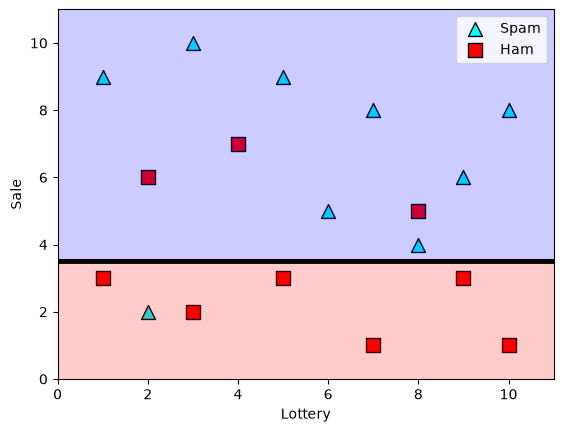

In [18]:
plot_model(features, labels, adaboost_classifier)

### ¿Cuánto vota cada muñón?

Esta tabla muestra, para cada uno de los 6 muñones **en el orden en que se entrenaron**:
- **`error`**: su error ponderado (con los pesos de los correos en ese momento).
- **`peso (alpha)`**: cuánto pesa su voto en la decisión final.

Observen que el **error tiende a subir** con cada ronda: los muñones posteriores se enfrentan a los correos más difíciles (los que acumularon más peso). Y, por la fórmula, **a más error, menos peso** en la votación.

In [19]:
pesos_adaboost = pd.DataFrame({
    "muñón": range(1, len(adaboost_classifier.estimators_) + 1),
    "error": adaboost_classifier.estimator_errors_.round(3),
    "peso (alpha)": adaboost_classifier.estimator_weights_.round(3),
})
pesos_adaboost

,muñón,error,peso (alpha)
0,1,0.222,1.253
1,2,0.232,1.196
2,3,0.324,0.736
3,4,0.337,0.677
4,5,0.418,0.331
5,6,0.390,0.446


### Los 6 muñones de AdaBoost, uno por uno

Cada gráfica es la frontera de un muñon individual, en el orden de entrenamiento. Pongan atención a cómo **cambia la línea** de un muñon al siguiente: cada uno intenta corregir a los correos que el anterior clasificó mal.

> Algún muñon puede salir de **un solo color**: con los pesos que tenía en ese momento, predice la misma clase a ambos lados. Su aporte es un "empujón" general hacia esa clase en la votación ponderada.

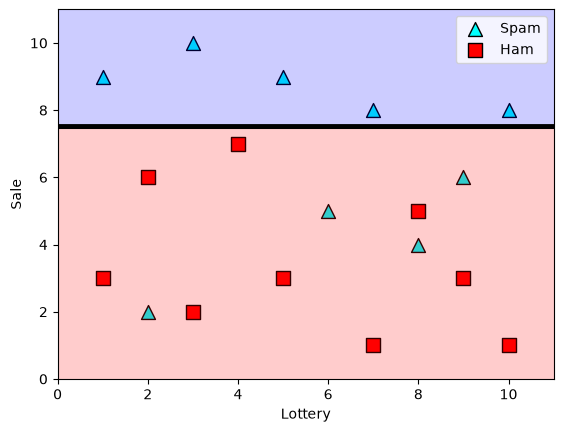

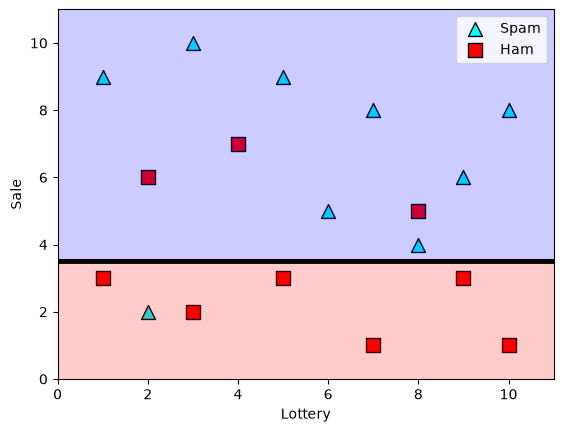

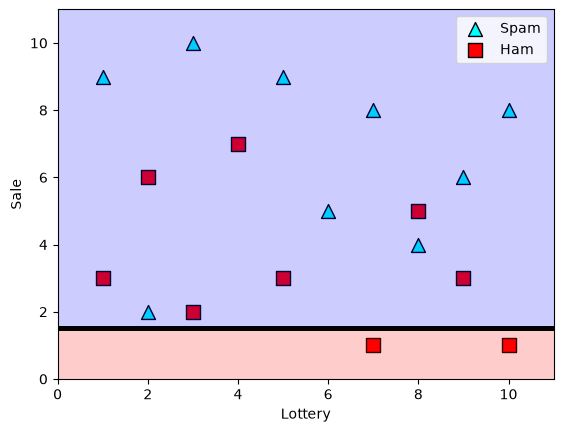

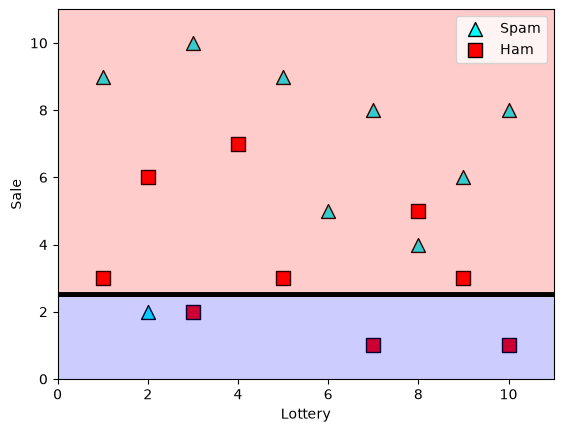

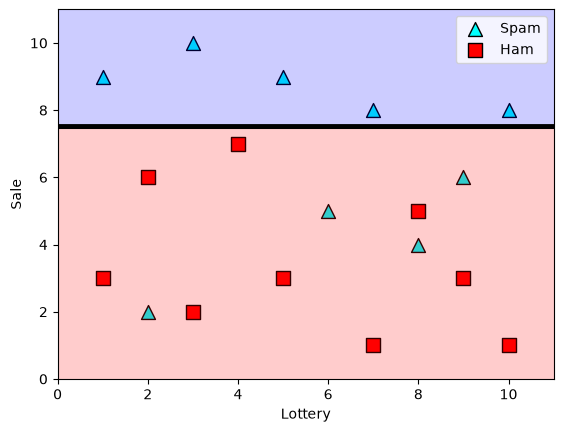

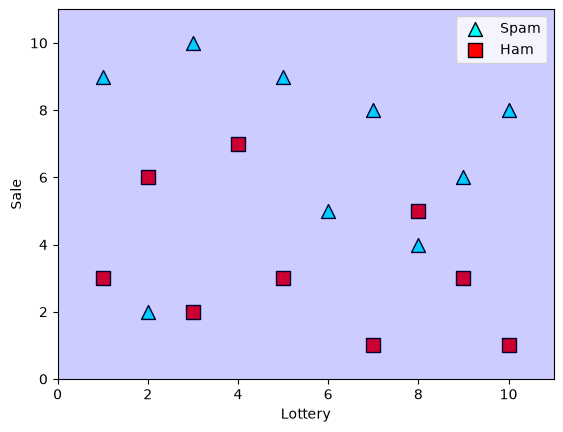

In [20]:
estimators = adaboost_classifier.estimators_
for estimator in estimators:
    plot_model(features, labels, estimator)
    plt.show()

## 8. Boosting moderno: Gradient Boosting y XGBoost

Estos son los métodos de boosting que más se usan hoy en la práctica con datos tabulares.

### Gradient Boosting

La idea es parecida a AdaBoost (modelos en secuencia que corrigen al anterior), pero la forma de corregir cambia:

- En lugar de **re-pesar** los correos, cada árbol nuevo se entrena para predecir el **residuo**: la diferencia entre lo que el modelo acumulado predice y la respuesta correcta (técnicamente, el **gradiente** de la función de pérdida; de ahí el nombre).
- La predicción final es la **suma** de las contribuciones de todos los árboles, cada una multiplicada por una tasa de aprendizaje (`learning_rate`, 0.1 por defecto) para avanzar en pasos pequeños.
- En clasificación, lo que se va sumando son **log-odds** (una escala de "qué tan probable es que sea spam"), por eso los árboles internos son **árboles de regresión**.
- Por defecto cada árbol tiene **`max_depth=3`** (no son tocones).

Parámetros: **`n_estimators=5`** árboles. Resultado esperado: **accuracy ≈ 0.89**.

In [21]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_classifier = GradientBoostingClassifier(random_state=0, n_estimators=5)
gradient_boosting_classifier.fit(features, labels)
gradient_boosting_classifier.score(features, labels)

0.8888888888888888

### Frontera de decisión de Gradient Boosting

Buen accuracy, pero sin las "islas" del árbol profundo de la sección 4: el modelo es preciso **sin** llegar a memorizar cada punto.

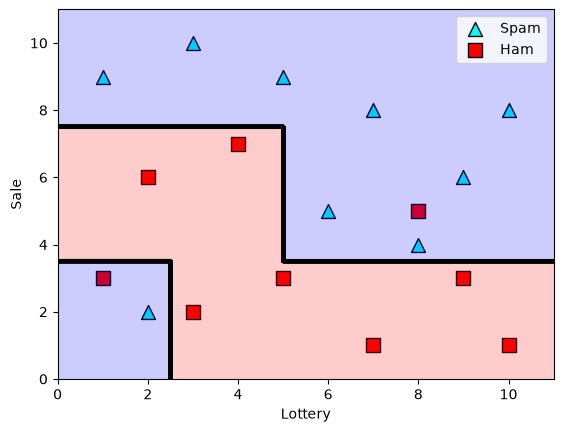

In [22]:
plot_model(features, labels, gradient_boosting_classifier)

### Los árboles internos de Gradient Boosting

A diferencia de Random Forest o AdaBoost, donde `.estimators_` es una **lista simple** de árboles, en Gradient Boosting `.estimators_` es una **matriz** (array 2D) de forma `(n_estimators, 1)`:

| Estructura | Random Forest | AdaBoost | Gradient Boosting |
|-----------|---------------|----------|-------------------|
| `.estimators_` | Lista de 5 árboles | Lista de 6 árboles | Matriz 5 × 1 |
| Acceso | `estimators[0]` | `estimators[0]` | `estimators[0][0]` |

**¿Por qué Gradient Boosting es una matriz?**

- Cada **fila** = una ronda de boosting (5 filas = 5 rondas).
- Cada **columna** = un árbol por ronda (normalmente 1, pero técnicamente podría haber más).
- La estructura matricial está pensada para casos más generales donde se entrenen múltiples árboles por ronda.

**Por eso para acceder al primer árbol usamos `estimators[0][0]`** (fila 0, columna 0).

Veámoslo en código:

In [23]:
estimators = gradient_boosting_classifier.estimators_
estimators.shape   # (5, 1): 5 rondas, 1 árbol por ronda

(5, 1)

Dibujemos el **primer árbol**. Noten dos diferencias con los árboles anteriores:

- Es un **árbol de regresión**: las hojas no dicen "spam" o "ham", sino un **número** (`value`). Ese número es la corrección (en escala de log-odds) que este árbol suma a la predicción. Valores positivos empujan hacia spam; negativos, hacia ham.
- Usa **`friedman_mse`** como criterio en lugar de `gini`, porque está prediciendo un número, no una clase.

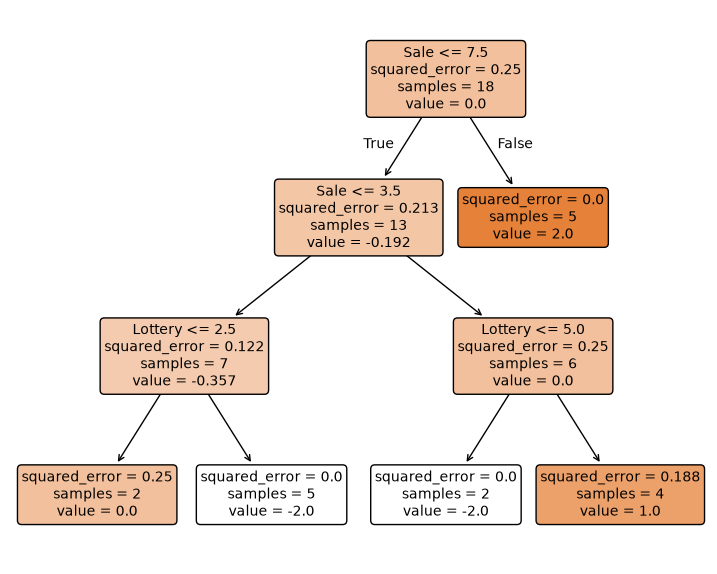

In [24]:
display_tree(estimators[0][0])

### XGBoost (*eXtreme Gradient Boosting*)

XGBoost es una implementación de gradient boosting muy optimizada y muy popular en competencias y en la industria. La idea base es la misma, pero agrega:

- **Regularización** (parámetros `reg_lambda`, `gamma`, ...) que penaliza árboles demasiado complejos → menos overfitting.
- Usa información de **segundo orden** (la curvatura de la pérdida) para decidir mejor las divisiones y los valores de las hojas.
- **Manejo automático de valores faltantes**, **paralelización** y otras optimizaciones de velocidad.
- Valores por defecto distintos a `sklearn`: `learning_rate=0.3` y `max_depth=6`.

> 📝 XGBoost no viene con `scikit-learn`; si no está instalado: `pip install xgboost`.
>
> Entrenamos con `np.array(features)` en lugar del `DataFrame` porque XGBoost es estricto con los nombres de columnas: si entrena con nombres y luego `plot_model` le pide predecir sobre un arreglo sin nombres, puede fallar.

Parámetros: **`n_estimators=5`**. Resultado esperado: **accuracy ≈ 0.89**.

In [25]:
import xgboost
from xgboost import XGBClassifier

xgboost_classifier = XGBClassifier(random_state=0, n_estimators=5)
xgboost_classifier.fit(np.array(features), labels)
xgboost_classifier.score(np.array(features), labels)

0.8888888888888888

### Frontera de decisión de XGBoost

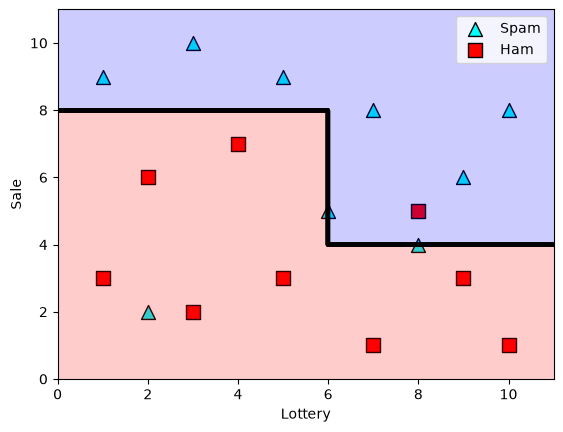

In [26]:
plot_model(features, labels, xgboost_classifier)

### El primer árbol de XGBoost

Mostramos el primer árbol en formato de texto (el formato gráfico requiere tener Graphviz instalado en el sistema; si lo está, también se dibuja).

Cómo leerlo:
- `f0` = **Lottery** y `f1` = **Sale** (las columnas en orden).
- `[f1<8] yes=1,no=2` significa: "¿Sale < 8? Si sí, ve al nodo 1; si no, al nodo 2".
- `leaf=...` es la contribución de esa hoja en **log-odds**: positiva empuja hacia spam, negativa hacia ham.

In [30]:
import shutil

# Versión en texto (siempre funciona)
print(xgboost_classifier.get_booster().get_dump()[0])

# Versión gráfica, solo si Graphviz está instalado en el sistema
if shutil.which("dot"):
    from IPython.display import display
    display(xgboost.to_graphviz(xgboost_classifier, tree_idx=0))

0:[f1<8] yes=1,no=2,missing=2
	1:[f1<4] yes=3,no=4,missing=4
		3:leaf=-0.272727281
		4:leaf=-0
	2:leaf=0.333333373



## 9. Resumen: comparemos todos los modelos

Reunimos el accuracy de entrenamiento de todos los modelos que construimos hoy.

In [28]:
resumen = pd.DataFrame({
    "Modelo": [
        "Árbol de decisión (sin límite)",
        "Random forest a mano (3 tocones)",
        "Random forest sklearn (5 tocones)",
        "AdaBoost (6 tocones)",
        "Gradient Boosting (5 árboles)",
        "XGBoost (5 árboles)",
    ],
    "Familia": ["—", "Bagging", "Bagging", "Boosting", "Boosting", "Boosting"],
    "Accuracy (entrenamiento)": [
        decision_tree_classifier.score(features, labels),
        bosque_manual.score(features, labels),
        random_forest_classifier.score(features, labels),
        adaboost_classifier.score(features, labels),
        gradient_boosting_classifier.score(features, labels),
        xgboost_classifier.score(np.array(features), labels),
    ],
})
resumen["Accuracy (entrenamiento)"] = resumen["Accuracy (entrenamiento)"].round(2)
resumen

,Modelo,Familia,Accuracy (entrenamiento)
0,Árbol de decisión (sin límite),—,1.00
1,Random forest a mano (3 tocones),Bagging,0.83
2,Random forest sklearn (5 tocones),Bagging,0.83
3,AdaBoost (6 tocones),Boosting,0.78
4,Gradient Boosting (5 árboles),Boosting,0.89
5,XGBoost (5 árboles),Boosting,0.89


### Conclusiones

1. **Un árbol sin límites memoriza** los datos (100 % en entrenamiento) con fronteras muy recortadas → alto riesgo de overfitting.
2. **Muchos modelos débiles combinados** logran buen desempeño con fronteras mucho más simples. Los errores individuales se compensan.
3. **Bagging (Random Forest):** modelos independientes en paralelo + votación → reduce la **varianza**.
4. **Boosting (AdaBoost, Gradient Boosting, XGBoost):** modelos en secuencia, cada uno corrige al anterior → reduce el **sesgo**.
5. **Gradient Boosting y XGBoost** son hoy el estándar en datos tabulares; XGBoost agrega regularización y optimizaciones de velocidad.

> ⚠️ **Advertencia importante:** toda la comparación de hoy usa accuracy **en los mismos datos de entrenamiento**, y con solo 18 correos. Sirve para *ver* cómo se comportan los modelos, **no** para decidir cuál es mejor. En un proyecto real:
> - Separamos datos de **entrenamiento y prueba** (o usamos **validación cruzada**).
> - **Ajustamos los hiperparámetros** (`n_estimators`, `max_depth`, `learning_rate`, ...) buscando el mejor desempeño en datos que el modelo **no** vio.

### 💬 Preguntas para discutir

- ¿Qué pasa con el random forest si subimos `n_estimators` a 100? ¿Y si subimos `max_depth` a 3?
- ¿Qué pasa con AdaBoost si usamos `n_estimators=50`? ¿Llegará a 100 % en entrenamiento? ¿Es eso bueno?
- En Gradient Boosting, ¿qué esperan que ocurra si bajamos `learning_rate` a 0.01 con solo 5 árboles?